# MECH5720 Lecture 4: the 2D DFT

The frequency axes on every DFT plot are labelled 0-based, because that is
how the DFT is defined: bin 0 is DC, bin k is k cycles across the image,
and numpy's array indexing matches. For a real image the DFT is conjugate
symmetric: the partner of bin `(r, c)` in an N-by-N transform is
`((-r) % N, (-c) % N)`, so a single real cosine lives in two bins.

| Section | What it shows |
| --- | --- |
| 1. The DFT matrix | Its rows are sampled complex exponentials, one per frequency. |
| 2. A single 2D cosine | Where one cosine lands in the 2D DFT, with and without `fftshift`. |
| 3. Simple shapes | Bars, boxes, a rotated box, a disk, and their DFTs. |
| 4. Filtering a shape | A shape, its DFT, a frequency-domain filter, and the result. |
| 5. A real photo | `dirt.jpg` and its DFT, compressed with a fourth root. |
| 6. Filtering a photo | Remove low vertical frequencies and see what survives. |
| 7. Sharpening | Keep everything, boost the high frequencies. |
| 8. 2D cosine explorer | Set frequency and phase, view the wave and its surface. |
| 9. One DFT bin per colour channel | Pull a single frequency out of each channel. |
| 10. Sum of random 2D cosines | Any image is a sum of cosines; add them one at a time. |
| 11. Rebuild an image, greedy | Largest DFT coefficient first, one wave at a time. |
| 12. The same, per colour channel | |
| 13. Pulse detection from video | A 1D DFT along time finds a heart rate, then amplifies it. |

## Stepping the animations

Sections 10, 11 and 12 were animations in the original scripts. Here each
is split into an **init** cell that resets the shared state and a **step**
cell that advances it by `STEP` iterations and redraws. Put the cursor in
the step cell and press **Ctrl-Enter** repeatedly to watch it evolve;
re-run the init cell to start over. This is the notebook version of a
`for` loop that draws every iteration: the loop body is a cell, and the
loop counter lives in a global variable.

Section 8 (the slider demo) uses the same idea: edit the parameters cell
and re-run. Section 13 ends with a real inline video player.

## Setup

Imports and the shared helpers.

In [42]:
%matplotlib inline
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ASSETS = Path("assets/Lec4")   # run the notebook from the LectureCode/ folder

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.figsize": (7.5, 5.5),
    "axes.grid": False,
    "image.interpolation": "nearest",
    "font.size": 12,
})
YEL = (1.0, 0.85, 0.15)


def load_image(name, channel=None):
    '''read an image in assets/Lec4 as float64 in [0, 1] (like im2double).
    channel=None returns HxWx3; channel=0/1/2 returns that plane (R/G/B).'''
    path = Path(name)
    if not path.is_absolute():
        path = ASSETS / path
    a = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64) / 255.0
    return a if channel is None else a[:, :, channel]


def imagesc(ax, img, clim=None, cmap="gray", **kw):
    '''imagesc + axis image. 2D uses a colormap; HxWx3 is shown as colour.
    Complex input (straight out of ifft2) is shown as its real part.'''
    img = np.asarray(img)
    if np.iscomplexobj(img):
        img = img.real
    if img.ndim == 3:
        h = ax.imshow(np.clip(img, 0, 1), aspect="equal", **kw)
    else:
        vmin, vmax = (None, None) if clim is None else clim
        h = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", **kw)
    ax.set_xticks([]); ax.set_yticks([])
    return h


def nice3(ax, a, cmap="viridis"):
    '''Shaded surface plot of a 2D array. ax must be a 3D axes.'''
    a = np.asarray(a)
    if np.iscomplexobj(a):
        a = a.real
    elev, azim = ax.elev, ax.azim
    ax.cla()
    m, n = a.shape
    X, Y = np.meshgrid(np.arange(n), np.arange(m))
    surf = ax.plot_surface(X, Y, a, cmap=cmap, linewidth=0, antialiased=False,
                           rstride=max(1, m // 100), cstride=max(1, n // 100))
    ax.view_init(elev, azim)
    return surf


def dft_ticks(ax, shape, shifted=False, step=8):
    '''Label a DFT image with 0-based frequency indices. Call after
    imagesc(ax, X, origin="lower"). shifted=True labels from -N/2.'''
    rows, cols = shape[:2]
    for axis, n in (("x", cols), ("y", rows)):
        locs = np.r_[np.arange(0, n - step + 1, step), n - 1]
        labs = locs - n // 2 if shifted else locs
        if axis == "x":
            ax.set_xticks(locs, [str(v) for v in labs])
        else:
            ax.set_yticks(locs, [str(v) for v in labs])
    ax.set_xlabel("$f_u$"); ax.set_ylabel("$f_v$")


def _freq_grid(shape):
    '''f_v (rows) and f_u (cols) in cycles/sample, in fft2 order (DC at [0,0]).'''
    rows, cols = shape[:2]
    return np.meshgrid(np.fft.fftfreq(rows), np.fft.fftfreq(cols), indexing="ij")


def freq_lpf_2d(shape, bw):
    '''2D Gaussian lowpass filter in the frequency domain. bw is the 3 dB
    bandwidth in cycles/sample (0.5 is Nyquist). Apply as ifft2(fft2(x) * H).'''
    FV, FU = _freq_grid(shape)
    return 2.0 ** (-(FV**2 + FU**2) / (2 * bw**2))


def freq_line_filt_2d(shape, bw):
    '''Passband along the line f_v = 0: all horizontal frequencies, only
    vertical frequencies within bw (3 dB) of zero.'''
    FV, _ = _freq_grid(shape)
    return 2.0 ** (-(FV**2) / (2 * bw**2))


def conjugate_partner(row, col, shape):
    '''Index of the DFT bin that pairs with (row, col) for a real image.'''
    rows, cols = shape[:2]
    return (-row) % rows, (-col) % cols


def single_wave(X, row, col):
    '''The real 2D cosine that bin (row, col) of DFT X (and its mirror) encode.
    Returns (wave, magnitude).'''
    row2, col2 = conjugate_partner(row, col, X.shape)
    W = np.zeros_like(X)
    for r, c in ((row, col), (row2, col), (row2, col2), (row, col2)):
        W[r, c] = X[r, c]
    return np.fft.ifft2(W).real, abs(X[row, col])


def disk_kernel(r, oversample=8):
    '''Unit-sum disk of radius r on a (2r+1)^2 grid, edge pixels area-weighted.'''
    n = 2 * r + 1
    s = oversample
    c = np.arange(n * s) / s - r - 0.5 + 0.5 / s
    X, Y = np.meshgrid(c, c)
    fine = (X**2 + Y**2) <= r**2
    d = fine.reshape(n, s, n, s).mean(axis=(1, 3))
    return d / d.sum()


def rotate_image(x, angle_deg):
    '''Rotate about the centre with bilinear interpolation, same size out.'''
    from scipy.ndimage import rotate
    return rotate(x, angle_deg, reshape=False, order=1)

## 1. The DFT matrix

The rows of the DFT matrix are the basis functions: sampled complex
exponentials, one per frequency. `F[j, k] = exp(-2j*pi*j*k/N)`. It is not
orthonormal; divide by `sqrt(N)` if you want `F^-1 == F^H`. Below are the
real parts of rows 1 to 6 (1 to 6 cycles across N samples).

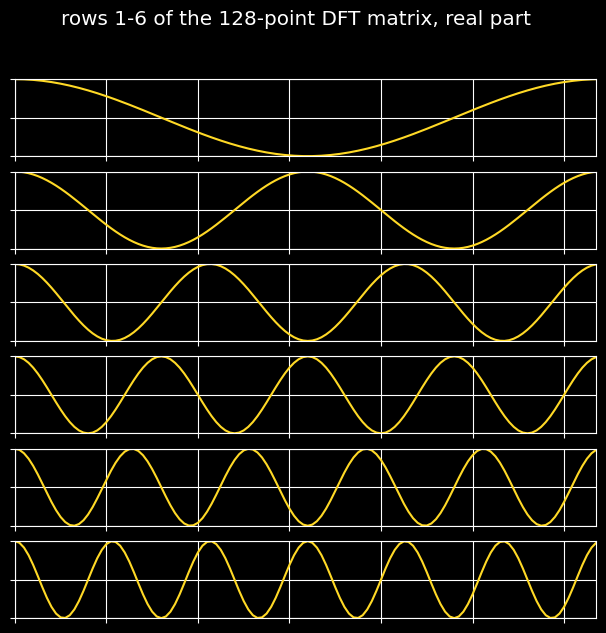

In [43]:
N = 128
k = np.arange(N)
F = np.exp(-2j * np.pi * np.outer(k, k) / N)

fig, axes = plt.subplots(6, 1, figsize=(7.5, 7))
for i, ax in enumerate(axes):
    ax.plot(k, F[i + 1, :].real, color=YEL)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.grid(True)
    ax.set_xlim(0, N - 1); ax.set_ylim(-1, 1)
fig.suptitle("rows 1-6 of the 128-point DFT matrix, real part");

## 2. A single 2D cosine, and where it lands in the 2D DFT

Edit the parameters and re-run. Things to try:
- DC only (`fx = fy = 0`)
- horizontal frequency only (`fy = 0`)
- horizontal frequency with DC
- vertical frequency only (`fx = 0`)
- mixed frequencies (uncomment the second wave)
- creep `fx` up through `ImgSize` and beyond, and watch it alias

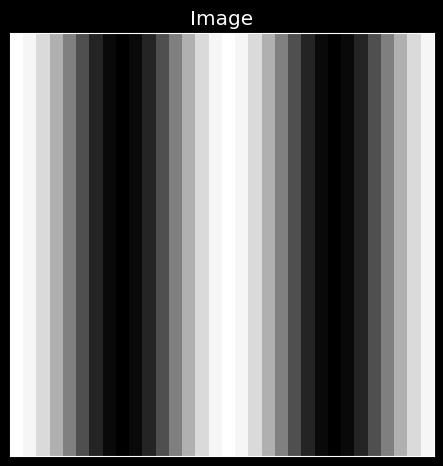

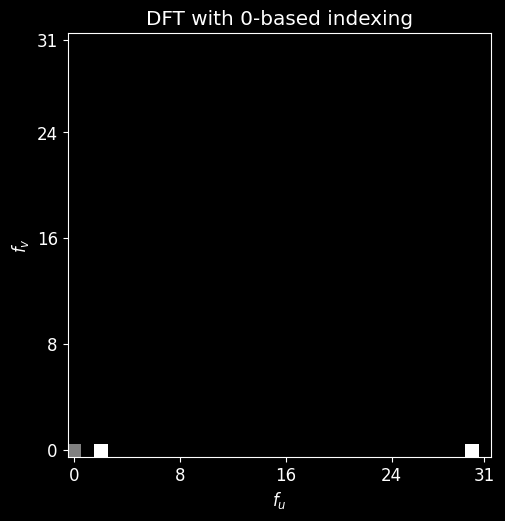

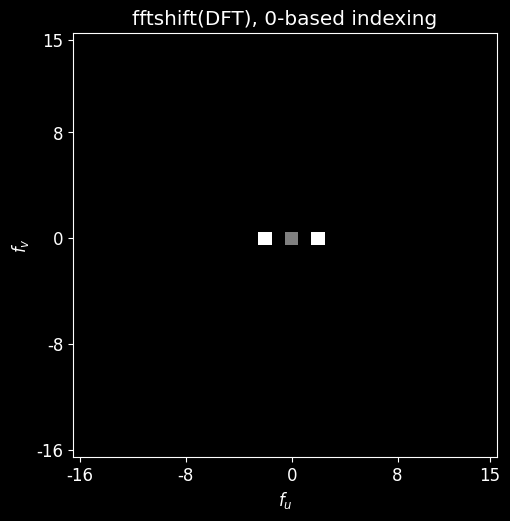

In [44]:
ImgSize = 32
X, Y = np.meshgrid(np.arange(ImgSize), np.arange(ImgSize))
phasex = phasey = 0

DC = 1 / 4
fx, fy = 2, 0
fx2, fy2 = 8, 6

x = DC + np.cos(2 * np.pi * fx / ImgSize * X + phasex) \
       * np.cos(2 * np.pi * fy / ImgSize * Y + phasey)
# x = x + np.cos(2*np.pi*fx2/ImgSize*X + phasex) * np.cos(2*np.pi*fy2/ImgSize*Y + phasey)

Xf = np.fft.fft2(x)

fig, ax = plt.subplots()
imagesc(ax, x); ax.set_title("Image")

fig, ax = plt.subplots()
imagesc(ax, np.abs(Xf), origin="lower"); dft_ticks(ax, Xf.shape)
ax.set_title("DFT with 0-based indexing")

fig, ax = plt.subplots()
imagesc(ax, np.fft.fftshift(np.abs(Xf)), origin="lower")
dft_ticks(ax, Xf.shape, shifted=True)
ax.set_title("fftshift(DFT), 0-based indexing");

## 3. Simple shapes and their 2D DFTs

Pick a shape by setting `SHAPE` below. Things to try: horizontal / vertical
bars of different width, a box of different width, a rotated box, a disk.

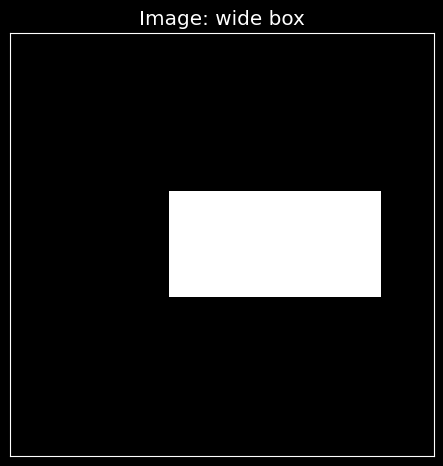

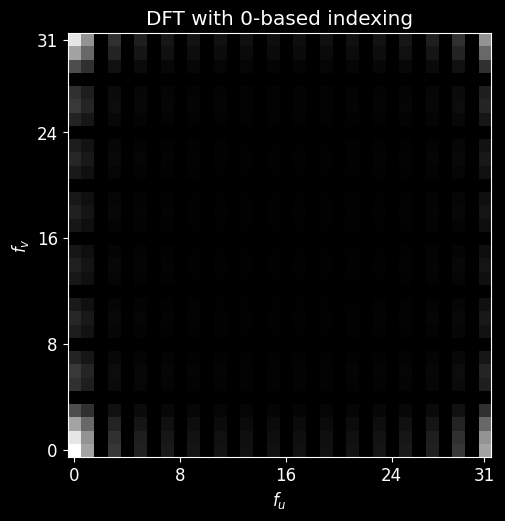

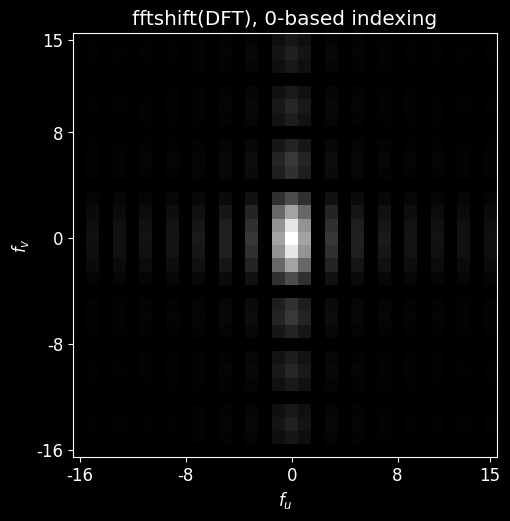

In [45]:
ImgSize = 32
SHAPE = "wide box"    # "vertical bar" | "square" | "tall box" | "wide box" | "rotated box" | "disk"

x = np.zeros((ImgSize, ImgSize))
w = ImgSize // 4
start = ImgSize // 2 - w // 2

if SHAPE == "vertical bar":
    x[:, start:start + w] = 1
elif SHAPE == "square":
    x[start:start + w, start:start + w] = 1
elif SHAPE == "tall box":
    x[start:start + 2 * w, start:start + w] = 1
elif SHAPE == "wide box":
    x[start:start + w, start:start + 2 * w] = 1
elif SHAPE == "rotated box":
    x[start:start + w, start:start + 2 * w] = 1
    x = rotate_image(x, 65)
elif SHAPE == "disk":
    d = disk_kernel(w - 1)
    wd = d.shape[0]
    s = ImgSize // 2 - wd // 2
    x[s:s + wd, s:s + wd] = d

Xf = np.fft.fft2(x)

fig, ax = plt.subplots()
imagesc(ax, x); ax.set_title(f"Image: {SHAPE}")

fig, ax = plt.subplots()
imagesc(ax, np.abs(Xf), origin="lower"); dft_ticks(ax, Xf.shape)
ax.set_title("DFT with 0-based indexing")

fig, ax = plt.subplots()
imagesc(ax, np.fft.fftshift(np.abs(Xf)), origin="lower")
dft_ticks(ax, Xf.shape, shifted=True)
ax.set_title("fftshift(DFT), 0-based indexing");

## 4. A shape, its DFT, a frequency-domain filter, and the result

The filter here is a Gaussian passband along `f_v = 0`, then inverted, so
it removes the low vertical frequencies and keeps everything else. Things
to try: the box instead of the disk, `freq_lpf_2d` instead of the line
filter, `H` instead of `1 - H`.

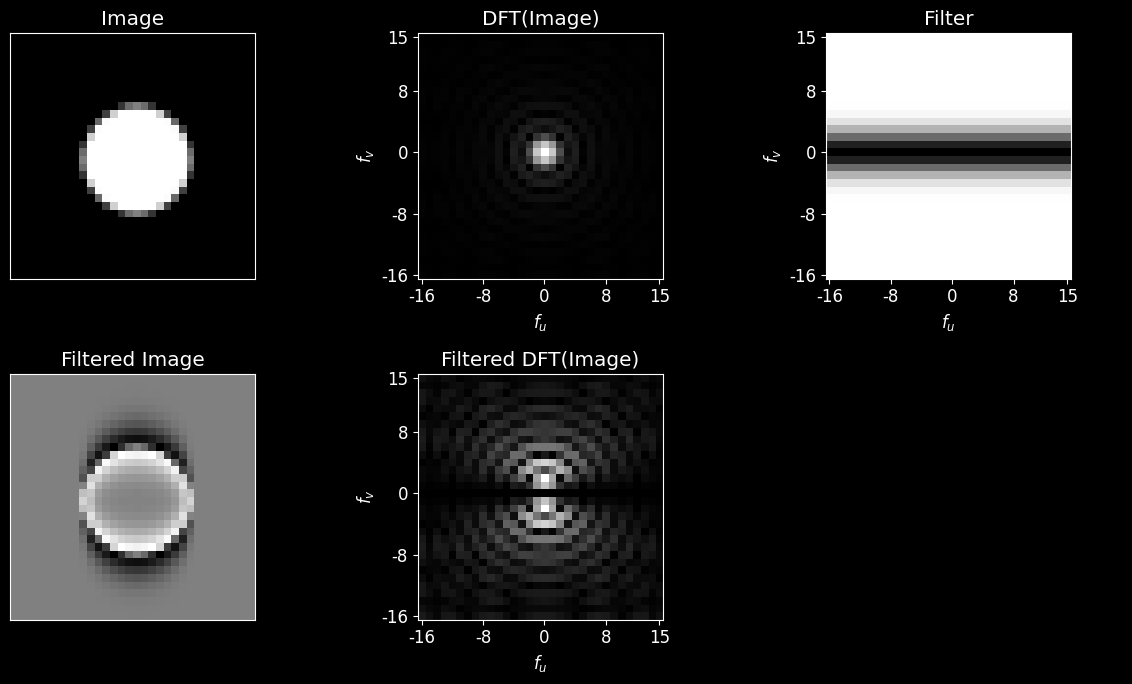

In [46]:
ImgSize = 32
x = np.zeros((ImgSize, ImgSize))
w = ImgSize // 4
start = ImgSize // 2 - w // 2

d = disk_kernel(w - 1)
wd = d.shape[0]
s = ImgSize // 2 - wd // 2
x[s:s + wd, s:s + wd] = d
# x[start:start + w, start:start + 2 * w] = 1   # the box instead

H = freq_line_filt_2d(x.shape, 0.05)
# H = freq_lpf_2d(x.shape, 0.1)
H = 1 - H

Xf = np.fft.fft2(x)
Xff = Xf * H
xf = np.fft.ifft2(Xff).real

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
imagesc(axes[0, 0], x); axes[0, 0].set_title("Image")
imagesc(axes[0, 1], np.fft.fftshift(np.abs(Xf)), origin="lower")
dft_ticks(axes[0, 1], Xf.shape, shifted=True); axes[0, 1].set_title("DFT(Image)")
imagesc(axes[0, 2], np.fft.fftshift(H), origin="lower")
dft_ticks(axes[0, 2], H.shape, shifted=True); axes[0, 2].set_title("Filter")
imagesc(axes[1, 0], xf); axes[1, 0].set_title("Filtered Image")
imagesc(axes[1, 1], np.fft.fftshift(np.abs(Xff)), origin="lower")
dft_ticks(axes[1, 1], Xff.shape, shifted=True); axes[1, 1].set_title("Filtered DFT(Image)")
axes[1, 2].axis("off")
fig.tight_layout();

## 5. A real photo and its 2D DFT

Compressed with a fourth root so the huge DC term does not swamp
everything else.

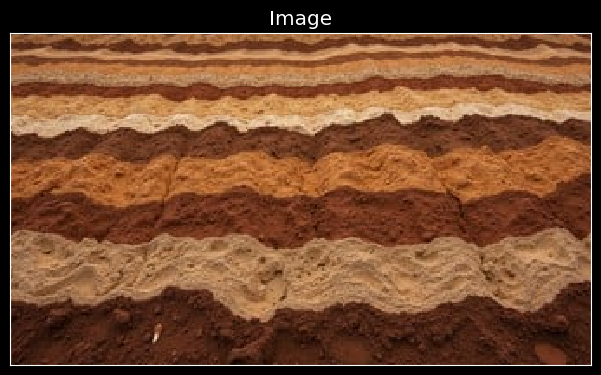

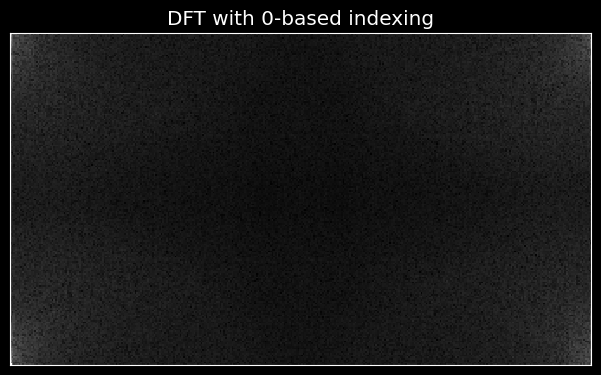

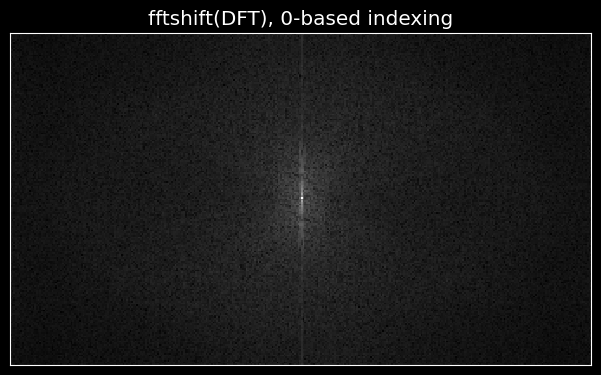

In [47]:
xc = load_image("dirt.jpg")     # colour, for display
x = xc[:, :, 1]                  # green channel, for the transform
Xf = np.fft.fft2(x)

fig, ax = plt.subplots()
imagesc(ax, xc); ax.set_title("Image")

fig, ax = plt.subplots()
imagesc(ax, np.abs(Xf) ** 0.25, origin="lower")
ax.set_title("DFT with 0-based indexing")

fig, ax = plt.subplots()
imagesc(ax, np.fft.fftshift(np.abs(Xf)) ** 0.25, origin="lower")
ax.set_title("fftshift(DFT), 0-based indexing");

## 6. Filtering a photo in the frequency domain

Remove the low vertical frequencies (the horizontal structure) and see
what survives. Things to try: `freq_lpf_2d` instead of the line filter,
`H` instead of `1 - H`, a wider or narrower bandwidth.

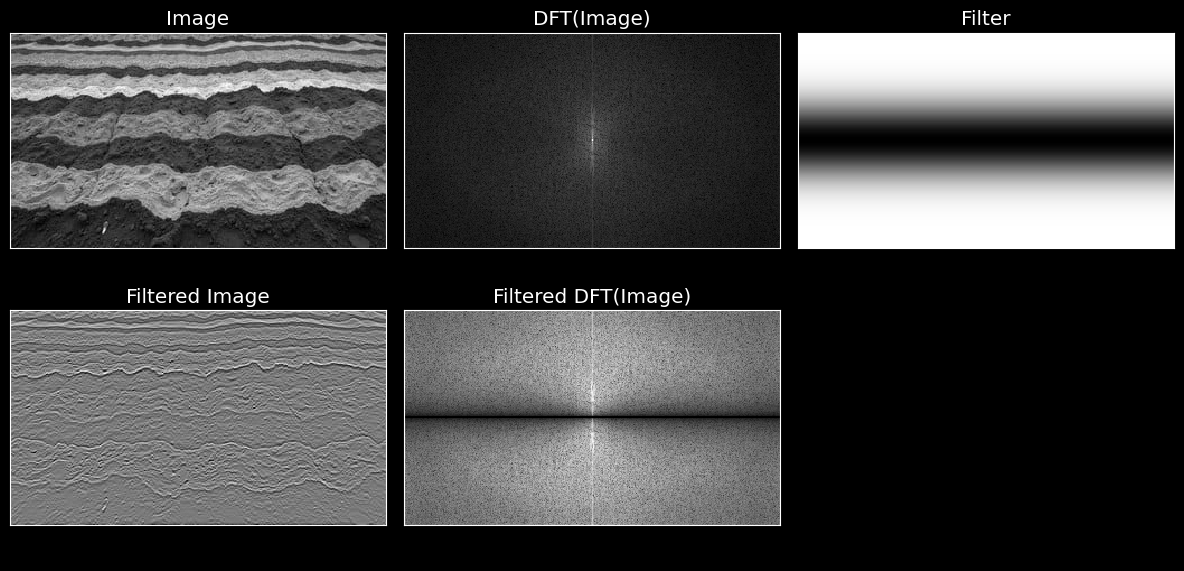

In [48]:
x = load_image("dirt.jpg", channel=1)

H = freq_line_filt_2d(x.shape, 0.1)
# H = freq_lpf_2d(x.shape, 0.1)
H = 1 - H

Xf = np.fft.fft2(x)
Xff = Xf * H
xf = np.fft.ifft2(Xff).real

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
imagesc(axes[0, 0], x); axes[0, 0].set_title("Image")
imagesc(axes[0, 1], np.fft.fftshift(np.abs(Xf)) ** 0.2, origin="lower")
axes[0, 1].set_title("DFT(Image)")
imagesc(axes[0, 2], np.fft.fftshift(H), origin="lower"); axes[0, 2].set_title("Filter")
imagesc(axes[1, 0], xf); axes[1, 0].set_title("Filtered Image")
imagesc(axes[1, 1], np.fft.fftshift(np.abs(Xff)) ** 0.2, origin="lower")
axes[1, 1].set_title("Filtered DFT(Image)")
axes[1, 2].axis("off")
fig.tight_layout();

## 7. Sharpening as a frequency-domain filter

Keep everything, and boost the high frequencies: `H = 1 + 2*(1 - LPF)`.
Things to try: a different bandwidth, a different boost factor, a plain
lowpass filter for blur.

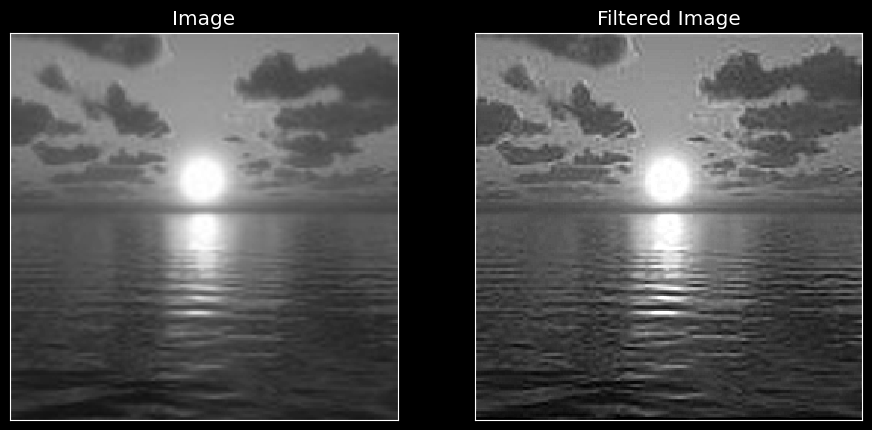

In [49]:
im = Image.open(ASSETS / "sunset_128.jpg")
im = im.resize((im.width * 2, im.height * 2), Image.BICUBIC)
x = np.asarray(im, dtype=float)[:, :, 1] / 255.0

H = freq_lpf_2d(x.shape, 0.1)
H = 1 - H            # highpass
H = 1 + 2 * H        # all of the image, plus twice its high frequencies

xf = np.fft.ifft2(np.fft.fft2(x) * H).real

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
imagesc(axes[0], x, [0, 1]); axes[0].set_title("Image")
imagesc(axes[1], xf, [0, 1]); axes[1].set_title("Filtered Image");

## 8. 2D cosine explorer

Set `f_x`, `f_y` and the two phases, re-run, and look at the wave and its
surface. (The original used live sliders; here it is a parameters cell.)

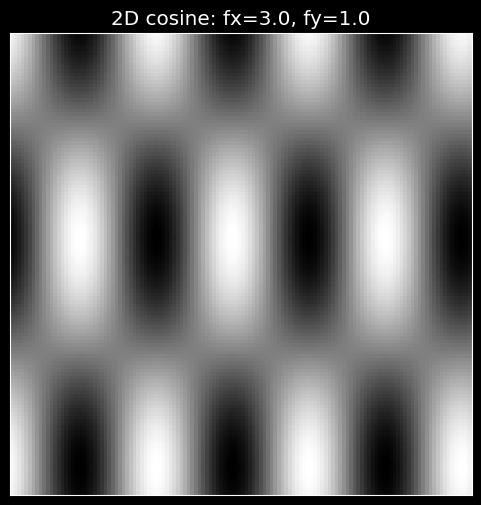

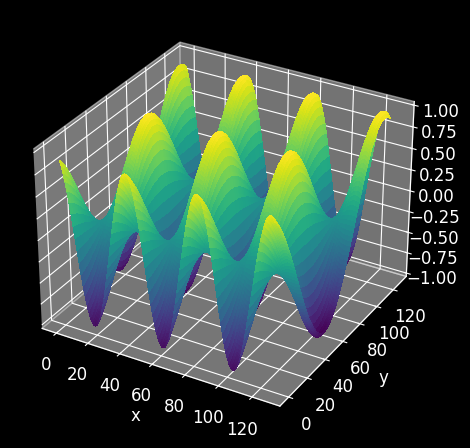

In [50]:
fx, fy = 3.0, 1.0
phasex, phasey = np.pi / 9, np.pi / 9

X, Y = np.meshgrid(np.linspace(0, 1, 128), np.linspace(0, 1, 128))
wave = np.cos(2 * np.pi * fx * X + phasex) * np.cos(2 * np.pi * fy * Y + phasey)

fig, ax = plt.subplots(figsize=(6, 6))
imagesc(ax, wave, [-1, 1]); ax.set_title(f"2D cosine: fx={fx}, fy={fy}")

fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection="3d")
nice3(ax, wave)
ax.set_xlabel("x"); ax.set_ylabel("y");

## 9. One DFT bin, one 2D wave, per colour channel

Pick a single frequency `(row, col)` out of each colour channel's DFT and
inverse-transform it on its own. Things to try: a different `(row, col)`,
or `row = 0` / `col = 0` for a purely horizontal or vertical wave.

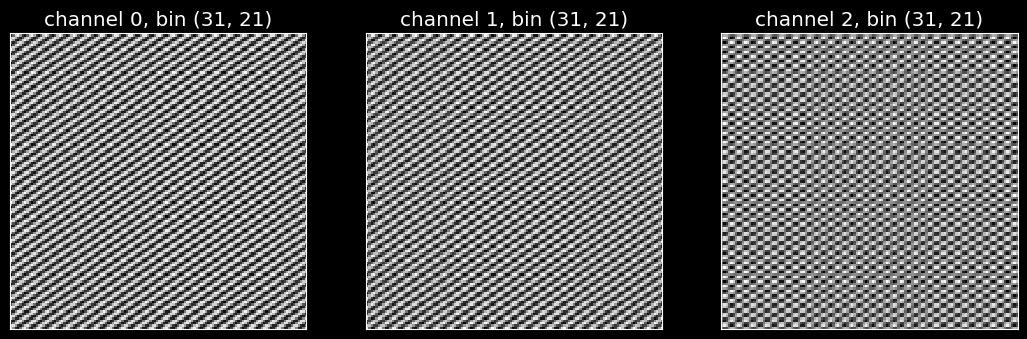

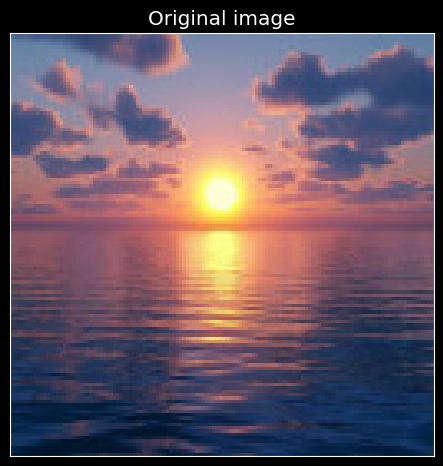

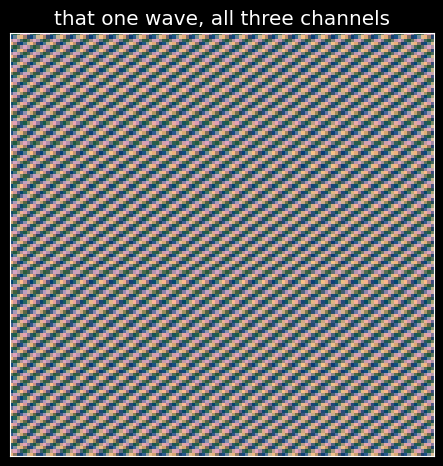

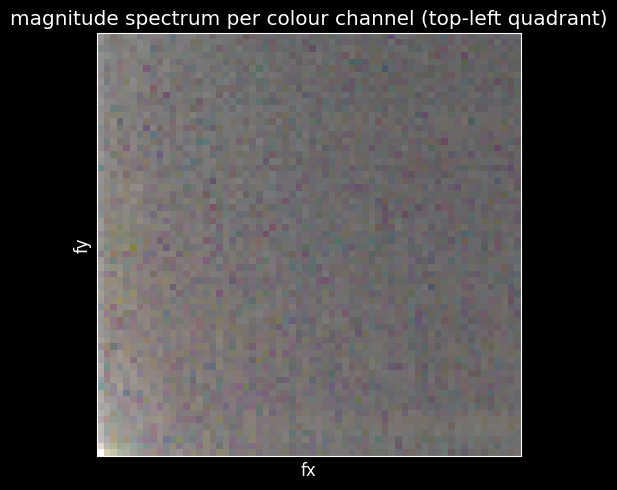

In [51]:
I = load_image("sunset_128.jpg")
ImSize = I.shape[0]
row, col = 31, 21          # 0-based DFT bin: 31 cycles down, 21 across

Rebuild = np.zeros_like(I)
NiceDisp = np.zeros_like(I)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ColChan in range(3):
    IF = np.fft.fft2(I[:, :, ColChan])
    CurWave, WaveMag = single_wave(IF, row, col)
    Rebuild[:, :, ColChan] = CurWave
    NiceDisp[:, :, ColChan] = np.abs(IF)
    imagesc(axes[ColChan], CurWave)
    axes[ColChan].set_title(f"channel {ColChan}, bin ({row}, {col})")

fig, ax = plt.subplots()
imagesc(ax, I); ax.set_title("Original image")

fig, ax = plt.subplots()
imagesc(ax, Rebuild / Rebuild.max() * 0.5 + 0.5)
ax.set_title("that one wave, all three channels")

fig, ax = plt.subplots()
imagesc(ax, (NiceDisp / NiceDisp.max()) ** 0.1, origin="lower")
ax.set_xlim(-0.5, 63.5); ax.set_ylim(-0.5, 63.5)
ax.set_xlabel("fx"); ax.set_ylabel("fy")
ax.set_title("magnitude spectrum per colour channel (top-left quadrant)");

## 10. Any image is a sum of 2D cosines

Add random ones together and watch a "picture" appear. **Init** resets;
each run of **step** adds `STEP` more waves.

In [52]:
# --- init: reset the running sum ---
ss_size = 200
ss_X, ss_Y = np.meshgrid(np.linspace(0, 1, ss_size), np.linspace(0, 1, ss_size))
ss_I = np.zeros((ss_size, ss_size))
ss_rng = np.random.default_rng(0)
ss_iter = 0
ss_freqs = []      # (fX, fY, amp) so far
print("reset")

reset


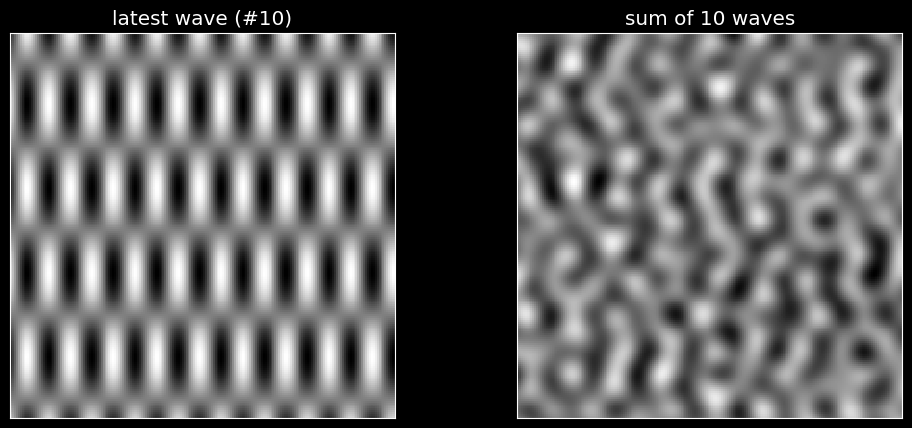

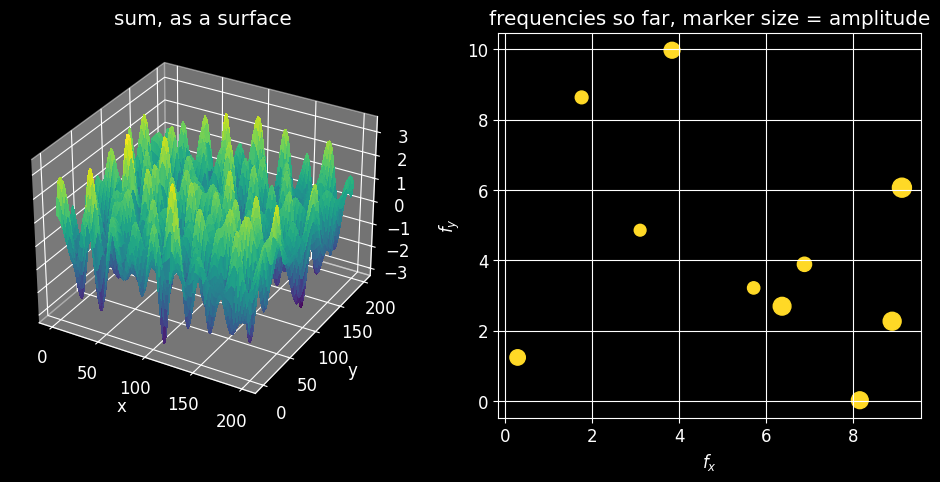

In [53]:
# --- step: run repeatedly with Ctrl-Enter ---
STEP = 10

for _ in range(STEP):
    fX, fY = 10 * ss_rng.random(), 10 * ss_rng.random()
    px, py = 2 * np.pi * ss_rng.random(), 2 * np.pi * ss_rng.random()
    amp = ss_rng.random()
    fval = amp * np.cos(2 * np.pi * fX * ss_X + px) * np.cos(2 * np.pi * fY * ss_Y + py)
    ss_I += fval
    ss_freqs.append((fX, fY, amp))
    ss_iter += 1

fq = np.array(ss_freqs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
imagesc(axes[0], fval); axes[0].set_title(f"latest wave (#{ss_iter})")
imagesc(axes[1], ss_I); axes[1].set_title(f"sum of {ss_iter} waves")

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection="3d")
nice3(ax, ss_I); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("sum, as a surface")
ax2 = fig.add_subplot(122)
ax2.scatter(fq[:, 0], fq[:, 1], s=200 * fq[:, 2], color=YEL)
ax2.set_xlabel("$f_x$"); ax2.set_ylabel("$f_y$")
ax2.set_title("frequencies so far, marker size = amplitude"); ax2.grid(True);

## 11. Rebuild an image one 2D wave at a time, greedy

Take the biggest remaining DFT bin (and its conjugate partner), turn it
into a wave, add it to the reconstruction, zero it, repeat. **Init**
resets; each run of **step** adds `STEP` waves.

In [54]:
# --- init ---
hs_I = load_image("sunset_128.jpg", channel=1)
hs_size = hs_I.shape[0]
hs_rebuild = np.zeros_like(hs_I)
hs_IF = np.fft.fft2(hs_I)
hs_nice = np.zeros(hs_IF.shape)
hs_iter = 0
print("reset")

reset


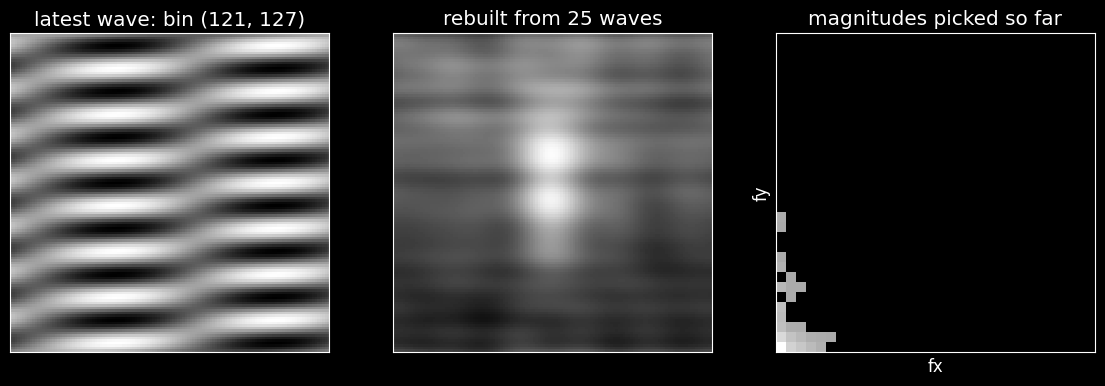

In [55]:
# --- step: run repeatedly with Ctrl-Enter ---
STEP = 25

for _ in range(STEP):
    idx = np.argmax(np.abs(hs_IF))
    row, col = np.unravel_index(idx, hs_IF.shape)
    row2, col2 = (-row) % hs_size, (-col) % hs_size
    CurWave, WaveMag = single_wave(hs_IF, row, col)
    hs_nice[min(row, row2), min(col, col2)] = WaveMag
    hs_rebuild += CurWave
    for r, c in ((row, col), (row2, col), (row2, col2), (row, col2)):
        hs_IF[r, c] = 0
    hs_iter += 1

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
imagesc(axes[0], CurWave); axes[0].set_title(f"latest wave: bin ({row}, {col})")
imagesc(axes[1], hs_rebuild, [0, 1]); axes[1].set_title(f"rebuilt from {hs_iter} waves")
imagesc(axes[2], (hs_nice / hs_nice.max()) ** 0.1, origin="lower")
axes[2].set_xlim(-0.5, 31.5); axes[2].set_ylim(-0.5, 31.5)
axes[2].set_xlabel("fx"); axes[2].set_ylabel("fy")
axes[2].set_title("magnitudes picked so far");

## 12. The same greedy reconstruction, per colour channel

Here the wave is subtracted from the image each time rather than zeroed in
the DFT, which comes to the same thing.

In [56]:
# --- init ---
hc_I = load_image("sunset_128.jpg")
hc_size = hc_I.shape[0]
hc_rebuild = np.zeros_like(hc_I)
hc_nice = np.zeros_like(hc_I)
hc_iter = 0
print("reset")

reset


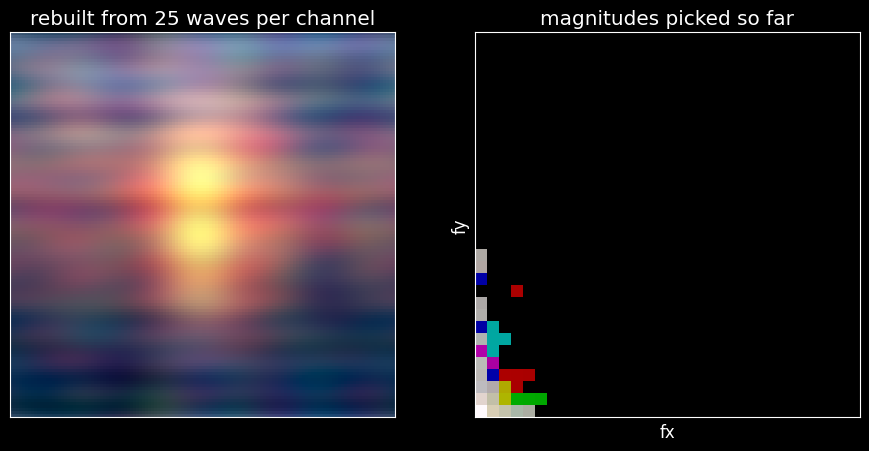

In [57]:
# --- step: run repeatedly with Ctrl-Enter ---
STEP = 25

for _ in range(STEP):
    for ColChan in range(3):
        IF = np.fft.fft2(hc_I[:, :, ColChan])
        idx = np.argmax(np.abs(IF))
        row, col = np.unravel_index(idx, IF.shape)
        row2, col2 = (-row) % hc_size, (-col) % hc_size
        CurWave, WaveMag = single_wave(IF, row, col)
        hc_nice[min(row, row2), min(col, col2), ColChan] = WaveMag
        hc_rebuild[:, :, ColChan] += CurWave
        hc_I[:, :, ColChan] -= CurWave
    hc_iter += 1

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
imagesc(axes[0], hc_rebuild); axes[0].set_title(f"rebuilt from {hc_iter} waves per channel")
imagesc(axes[1], (hc_nice / hc_nice.max()) ** 0.1, origin="lower")
axes[1].set_xlim(-0.5, 31.5); axes[1].set_ylim(-0.5, 31.5)
axes[1].set_xlabel("fx"); axes[1].set_ylabel("fy")
axes[1].set_title("magnitudes picked so far");

## 13. Pulse detection from a video of a face

Sum each frame to one number per colour channel: three noisy signals over
time. Their DFTs have a peak at the heart rate. Then amplify that one frequency in every pixel and play the video back
inline (last cell): the face visibly pulses at the heart rate.

Video from https://github.com/AnirudhBHarish/Pulse_Detection_From_Videos.
Needs `opencv-python` to read the mp4. `Shrink = 2` halves each axis: 301
frames at full size is over 1 GB in float32 and twice that inside the FFT.

In [58]:
import cv2
from scipy import fft   # keeps single precision; numpy.fft would upcast to complex128

Shrink = 2

cap = cv2.VideoCapture(str(ASSETS / "face.mp4"))
fps = cap.get(cv2.CAP_PROP_FPS)
frames = []
while True:
    ok, bgr = cap.read()
    if not ok:
        break
    if Shrink > 1:
        bgr = cv2.resize(bgr, None, fx=1 / Shrink, fy=1 / Shrink, interpolation=cv2.INTER_AREA)
    frames.append(bgr[:, :, ::-1])       # OpenCV gives BGR; flip to RGB
cap.release()

LF = np.stack(frames).astype(np.float32) / 255.0
NFrames = LF.shape[0]
print(f"{NFrames} frames at {fps:.0f} fps, {LF.shape[2]}x{LF.shape[1]} after {Shrink}x shrink")

301 frames at 30 fps, 264x296 after 2x shrink


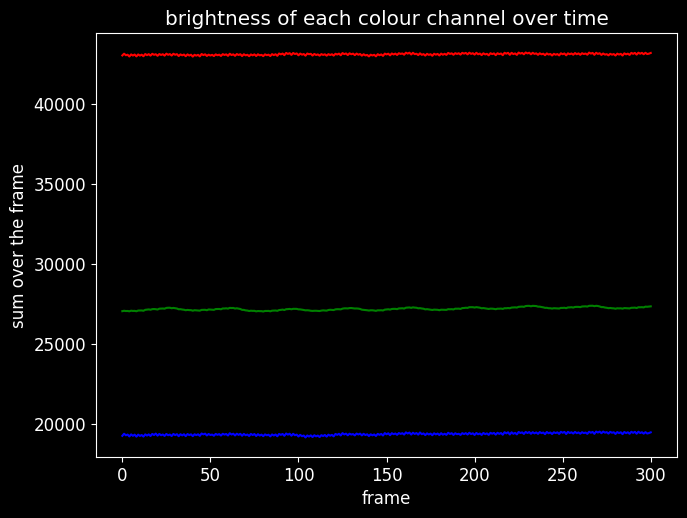

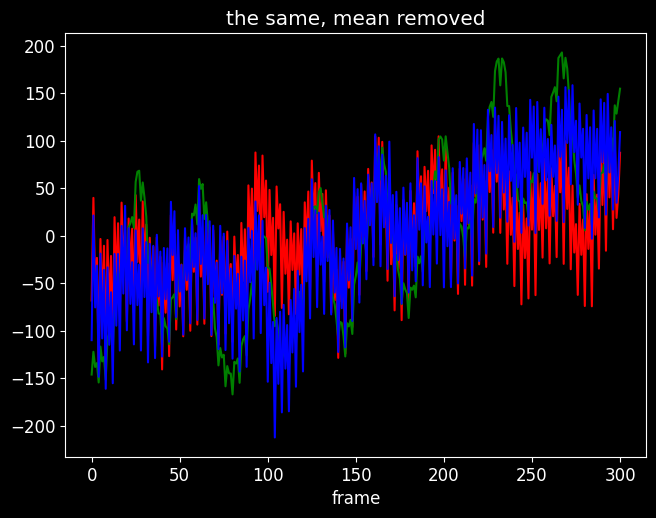

In [59]:
x = LF.sum(axis=(1, 2))          # NFrames x 3, one number per frame per channel

fig, ax = plt.subplots()
for c, col in enumerate("rgb"):
    ax.plot(x[:, c], col)
ax.set_xlabel("frame"); ax.set_ylabel("sum over the frame")
ax.set_title("brightness of each colour channel over time")

x = x - x.mean(axis=0)          # remove the mean, so DC does not dominate

fig, ax = plt.subplots()
for c, col in enumerate("rgb"):
    ax.plot(x[:, c], col)
ax.set_xlabel("frame"); ax.set_title("the same, mean removed");

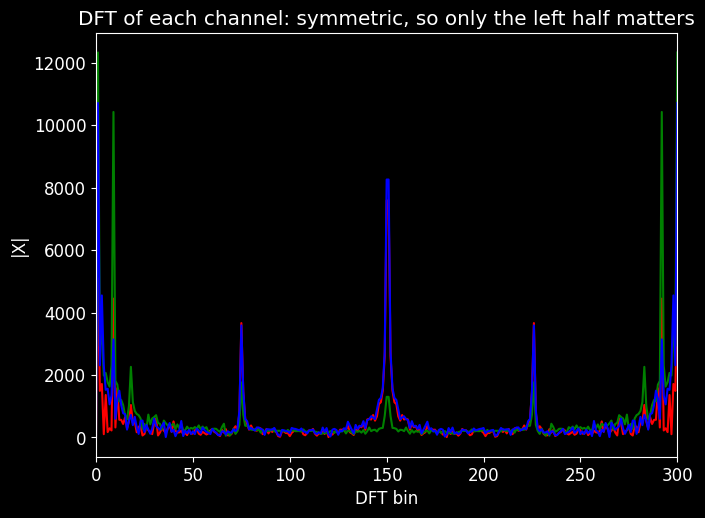

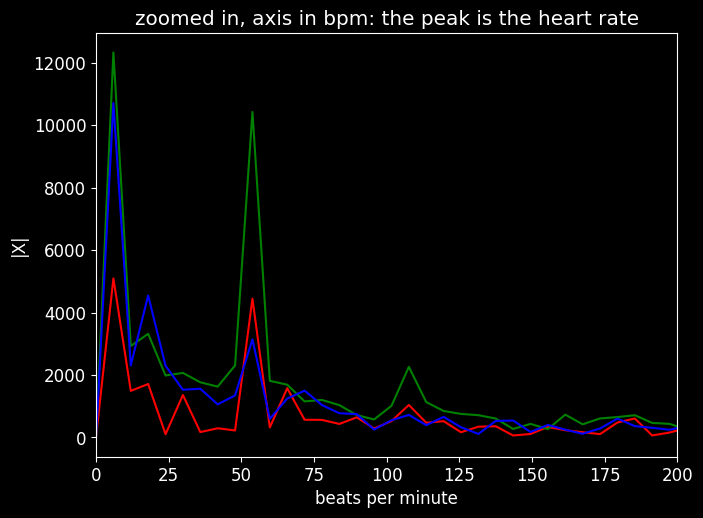

In [60]:
Xf = fft.fft(x, axis=0)
freqs = np.arange(NFrames) * fps / NFrames     # bin k is k*fps/N hertz

fig, ax = plt.subplots()
for c, col in enumerate("rgb"):
    ax.plot(np.abs(Xf[:, c]), col)
ax.set_xlim(0, NFrames - 1)
ax.set_xlabel("DFT bin"); ax.set_ylabel("|X|")
ax.set_title("DFT of each channel: symmetric, so only the left half matters")

fig, ax = plt.subplots()
half = NFrames // 2
for c, col in enumerate("rgb"):
    ax.plot(freqs[:half] * 60, np.abs(Xf[:half, c]), col)
ax.set_xlim(0, 200)
ax.set_xlabel("beats per minute"); ax.set_ylabel("|X|")
ax.set_title("zoomed in, axis in bpm: the peak is the heart rate");

amplifying bin 9: 0.90 Hz = 54 bpm
done: LFf is the amplified video


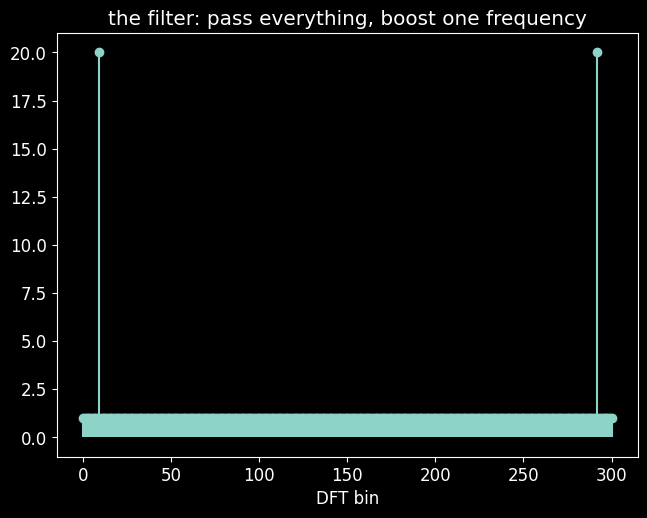

In [61]:
Idx = 9                    # 0-based DFT bin along time; see the bpm plot
# Idx = 18                 # harmonic of the heartbeat
Idx2 = NFrames - Idx       # its conjugate partner
print(f"amplifying bin {Idx}: {freqs[Idx]:.2f} Hz = {60 * freqs[Idx]:.0f} bpm")

Filt = np.ones(NFrames, dtype=np.float32)
Filt[Idx] = Filt[Idx2] = 20

fig, ax = plt.subplots()
ax.stem(Filt, basefmt=" ")
ax.set_xlabel("DFT bin"); ax.set_title("the filter: pass everything, boost one frequency")

# apply it along the time axis, one FFT per pixel per channel
LFF = fft.fft(LF, axis=0, overwrite_x=False)
LFF *= Filt[:, None, None, None]
LFf = np.clip(fft.ifft(LFF, axis=0, overwrite_x=True).real, 0, 1)
del LFF
print("done: LFf is the amplified video")

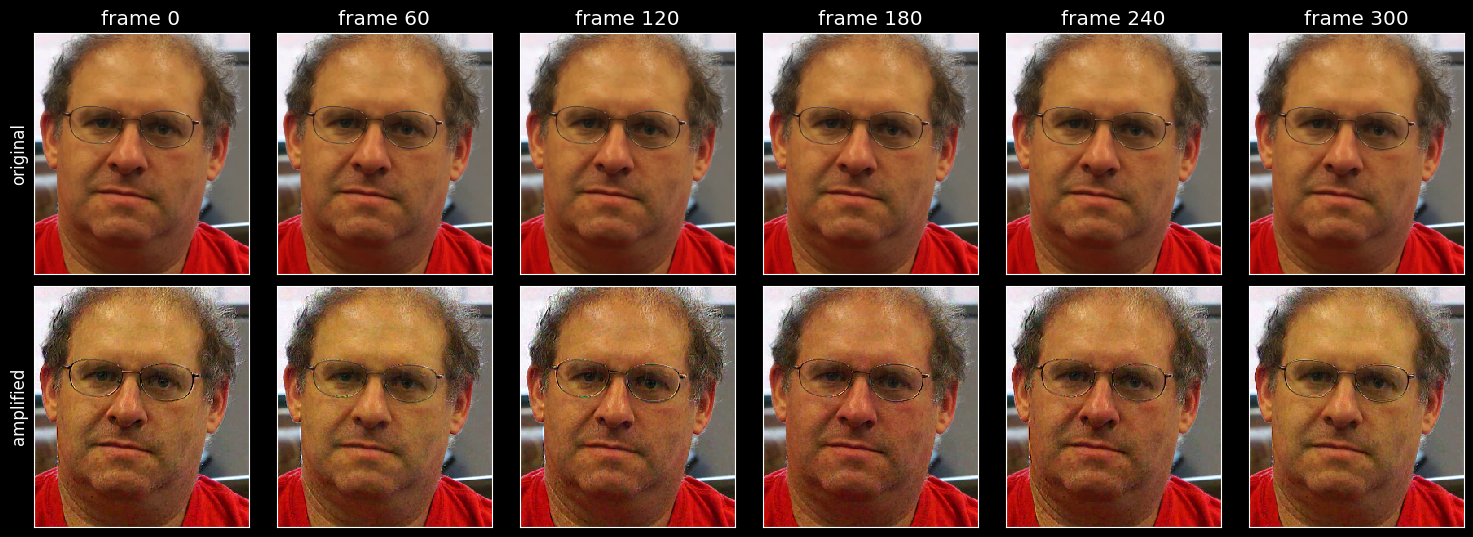

In [62]:
# a montage of frames, original (top) vs amplified (bottom)
picks = np.linspace(0, NFrames - 1, 6).astype(int)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5))
for j, fr in enumerate(picks):
    imagesc(axes[0, j], LF[fr]); axes[0, j].set_title(f"frame {fr}")
    imagesc(axes[1, j], LFf[fr])
axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("amplified")
fig.tight_layout();

In [63]:
# --- inline video: original vs pulse-amplified, playable in the notebook ---
import shutil
from matplotlib import animation
from IPython.display import HTML

ffmpeg = shutil.which("ffmpeg")
if ffmpeg is None:
    try:
        import imageio_ffmpeg                       # pip install imageio-ffmpeg
        ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
        matplotlib.rcParams["animation.ffmpeg_path"] = ffmpeg
    except Exception:
        ffmpeg = None

if ffmpeg:
    sel, fps_out, sub = range(NFrames), fps, np.s_[:, :]
else:
    print("No ffmpeg found. Showing a short, coarse fallback player.\n"
          "For the full-quality inline video:  pip install imageio-ffmpeg")
    matplotlib.rcParams["animation.embed_limit"] = 60   # MB
    sel, fps_out, sub = range(0, NFrames, 5), fps / 5, np.s_[::2, ::2]

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
for a in axes:
    a.set_xticks([]); a.set_yticks([])
im0 = axes[0].imshow(LF[0][sub]); axes[0].set_title("original")
im1 = axes[1].imshow(LFf[0][sub]); axes[1].set_title(f"pulse amplified (bin {Idx})")
plt.close(fig)   # suppress the static first frame

def _update(k):
    im0.set_data(LF[k][sub]); im1.set_data(LFf[k][sub])
    return im0, im1

anim = animation.FuncAnimation(fig, _update, frames=sel,
                               interval=1000 / fps_out, blit=True)
HTML(anim.to_html5_video() if ffmpeg else anim.to_jshtml(fps=fps_out))
